In [ ]:
# Cell 1: Import Libraries and Load Data
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

# Load the dataset
df = pd.read_csv('/content/attrition_balanced.csv')
# Label encode all object-type columns
df = df.apply(lambda col: LabelEncoder().fit_transform(col) if col.dtypes == 'object' else col)

# Drop redundant ID-like columns
df.drop(['EmployeeCount', 'EmployeeNumber', 'StandardHours', 'Over18'], axis=1, inplace=True)

# Features and target
X = df.drop('Attrition', axis=1)
y = df['Attrition']

# Min-Max Scaling
scaler = MinMaxScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, stratify=y, random_state=42)

df.head()

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,...,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition
0,41,2,1102,2,1,2,1,2,0,94,...,1,0,8,0,1,6,4,0,5,1
1,49,1,279,1,8,1,1,3,1,61,...,4,1,10,3,3,10,7,1,7,0
2,37,2,1373,1,2,2,4,4,1,92,...,2,0,7,3,3,0,0,0,0,1
3,33,1,1392,1,3,4,1,4,0,56,...,3,0,8,3,3,8,7,3,0,0
4,27,2,591,1,2,1,3,1,1,40,...,4,1,6,3,3,2,2,2,2,0


In [ ]:
# Cell 2: Define Evaluation Function
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score

def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        from sklearn.calibration import CalibratedClassifierCV
        model = CalibratedClassifierCV(model, cv="prefit")
        model.fit(X_train, y_train)
        y_prob = model.predict_proba(X_test)[:, 1]
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_prob)
    }

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).



Params: {'C': 0.1, 'kernel': 'linear'}
{'Model': "SVM {'C': 0.1, 'kernel': 'linear'}", 'Accuracy': 0.8076923076923077, 'Precision': 0.8166666666666667, 'Recall': 0.7935222672064778, 'AUC': np.float64(0.8824025963382451)}

Params: {'C': 1, 'kernel': 'rbf'}
{'Model': "SVM {'C': 1, 'kernel': 'rbf'}", 'Accuracy': 0.868421052631579, 'Precision': 0.8760330578512396, 'Recall': 0.8582995951417004, 'AUC': np.float64(0.9392220819879034)}

Params: {'C': 10, 'kernel': 'rbf'}
{'Model': "SVM {'C': 10, 'kernel': 'rbf'}", 'Accuracy': 0.8967611336032388, 'Precision': 0.892, 'Recall': 0.902834008097166, 'AUC': np.float64(0.9586946188267305)}

Params: {'C': 100, 'kernel': 'rbf'}
{'Model': "SVM {'C': 100, 'kernel': 'rbf'}", 'Accuracy': 0.8967611336032388, 'Precision': 0.892, 'Recall': 0.902834008097166, 'AUC': np.float64(0.9602353751085905)}


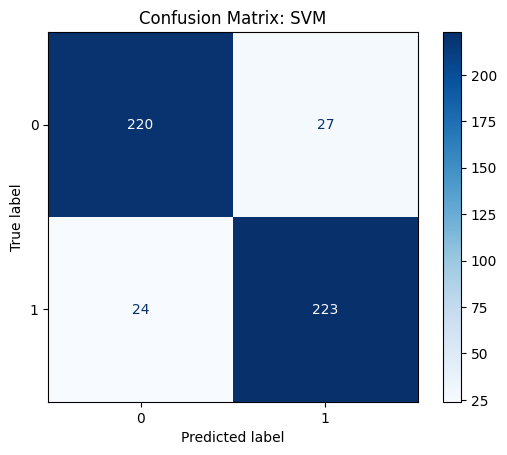

In [ ]:
# Cell 3: Train SVM with Hyperparameter Tuning
from sklearn.svm import SVC
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

options = [
    {'C': 0.1, 'kernel': 'linear'},
    {'C': 1, 'kernel': 'rbf'},
    {'C': 10, 'kernel': 'rbf'},
    {'C': 100, 'kernel': 'rbf'}
]

for params in options:
    model = SVC(**params, gamma='scale', probability=True)
    model.fit(X_train, y_train)
    print(f"\nParams: {params}")
    print(evaluate_model(f"SVM {params}", model, X_test, y_test))

# Confusion Matrix
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, cmap='Blues')
plt.title("Confusion Matrix: SVM")
plt.show()

✅ SVM Best Params: {'C': 10, 'kernel': 'rbf'}
SVM Tree Best Params: {'C': 10, 'kernel': 'rbf'}
{'Model': 'SVM', 'Accuracy': 0.8967611336032388, 'Precision': 0.892, 'Recall': 0.902834008097166, 'AUC': np.float64(0.958686423314593)}
              precision    recall  f1-score   support

           0       0.90      0.89      0.90       247
           1       0.89      0.90      0.90       247

    accuracy                           0.90       494
   macro avg       0.90      0.90      0.90       494
weighted avg       0.90      0.90      0.90       494



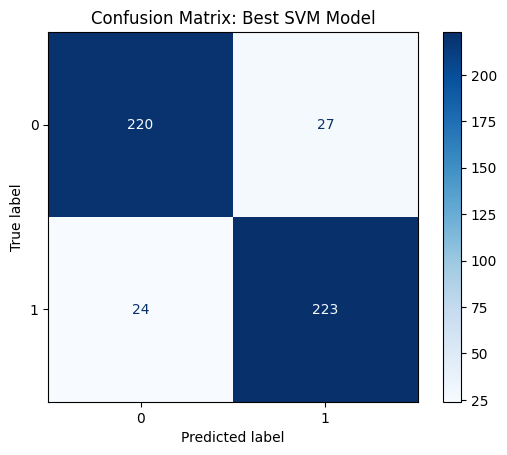

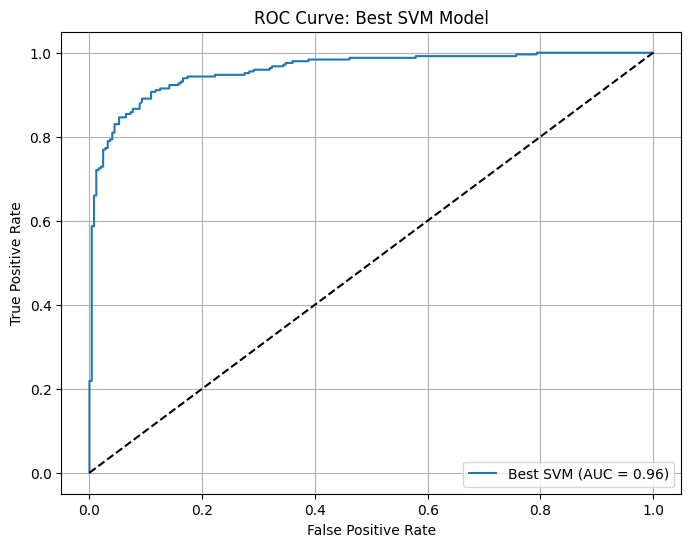

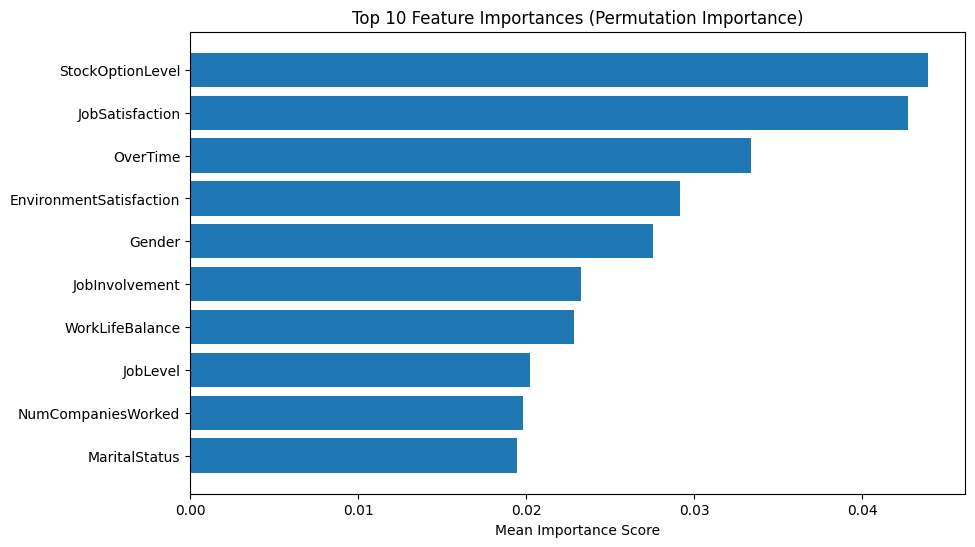

In [ ]:
# Cell 3 Backup: Train SVM with Hyperparameter Tuning using GridSearchCV
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, roc_curve, auc
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import numpy as np

# Define SVM hyperparameter grid
svm_params = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf']
}

# Set up GridSearchCV
svm = SVC(gamma='scale', probability=True, random_state=42)
svm_grid = GridSearchCV(svm, svm_params, cv=5, scoring='accuracy')
svm_grid.fit(X_train, y_train)

# Get the best model
best_svm = svm_grid.best_estimator_
print("✅ SVM Best Params:", svm_grid.best_params_)
svm_results = evaluate_model("SVM", best_svm, X_test, y_test)
print("SVM Tree Best Params:", svm_grid.best_params_)
print(svm_results)

# Evaluate the best SVM
y_pred = best_svm.predict(X_test)
print(classification_report(y_test, y_pred))

# Confusion Matrix
ConfusionMatrixDisplay.from_estimator(best_svm, X_test, y_test, cmap='Blues')
plt.title("Confusion Matrix: Best SVM Model")
plt.show()

# ROC Curve
y_proba = best_svm.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Best SVM (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Best SVM Model")
plt.legend(loc="lower right")
plt.grid()
plt.show()

# Feature Importance using Permutation Importance
result = permutation_importance(best_svm, X_test, y_test, n_repeats=10, random_state=42)

# Sort and plot top N features
top_n = 10
sorted_idx = result.importances_mean.argsort()[::-1]
plt.figure(figsize=(10, 6))
plt.barh(range(top_n), result.importances_mean[sorted_idx][:top_n], align='center')
plt.yticks(range(top_n), [X_train.columns[i] for i in sorted_idx[:top_n]])
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importances (Permutation Importance)")
plt.xlabel("Mean Importance Score")
plt.show()

Decision Tree Best Params: {'max_depth': 10, 'min_samples_split': 10}
{'Model': 'Decision Tree', 'Accuracy': 0.8016194331983806, 'Precision': 0.7689530685920578, 'Recall': 0.8623481781376519, 'AUC': np.float64(0.815084659640381)}


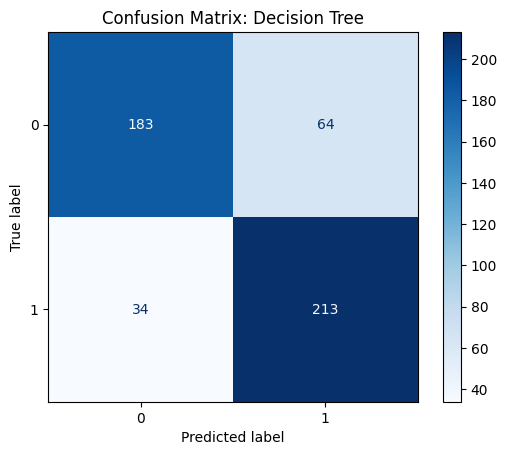

In [ ]:
# Cell 4: Train Decision Tree with Hyperparameter Tuning
from sklearn.tree import DecisionTreeClassifier

dt_params = {'max_depth': [3, 5, 10, None], 'min_samples_split': [2, 5, 10]}
dt = DecisionTreeClassifier(random_state=42)
dt_grid = GridSearchCV(dt, dt_params, cv=5, scoring='accuracy')
dt_grid.fit(X_train, y_train)

best_dt = dt_grid.best_estimator_
dt_results = evaluate_model("Decision Tree", best_dt, X_test, y_test)
print("Decision Tree Best Params:", dt_grid.best_params_)
print(dt_results)

# Confusion Matrix
ConfusionMatrixDisplay.from_estimator(dt_grid, X_test, y_test, cmap='Blues')
plt.title("Confusion Matrix: Decision Tree")
plt.show()

{'Model': 'Naive Bayes', 'Accuracy': 0.6781376518218624, 'Precision': 0.6538461538461539, 'Recall': 0.757085020242915, 'AUC': np.float64(0.7878837548558408)}


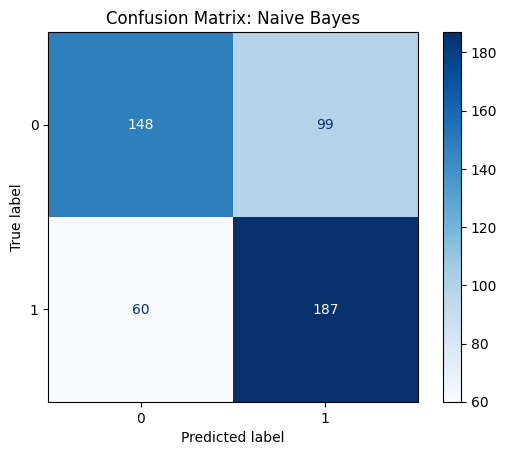

In [ ]:
# Cell 5: Train Naive Bayes
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
bb_model = nb.fit(X_train, y_train)
nb_results = evaluate_model("Naive Bayes", nb, X_test, y_test)
print(nb_results)

# Confusion Matrix
ConfusionMatrixDisplay.from_estimator(nb, X_test, y_test, cmap='Blues')
plt.title("Confusion Matrix: Naive Bayes")
plt.show()

In [ ]:
# Cell 6: Logistic Regression with Forward and Backward Selection
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

logreg = LogisticRegression(max_iter=1000)

# Forward Selection
forward_selector = SequentialFeatureSelector(logreg, direction='forward', cv=5)
forward_selector.fit(X_train, y_train)
X_train_fwd = forward_selector.transform(X_train)
X_test_fwd = forward_selector.transform(X_test)
logreg_fwd = logreg.fit(X_train_fwd, y_train)
logreg_fwd_results = evaluate_model("LogReg Forward", logreg_fwd, X_test_fwd, y_test)

# Backward Selection
backward_selector = SequentialFeatureSelector(logreg, direction='backward', cv=5)
backward_selector.fit(X_train, y_train)
X_train_bwd = backward_selector.transform(X_train)
X_test_bwd = backward_selector.transform(X_test)
logreg_bwd = logreg.fit(X_train_bwd, y_train)
logreg_bwd_results = evaluate_model("LogReg Backward", logreg_bwd, X_test_bwd, y_test)

if (logreg_fwd_results['Accuracy'] > logreg_bwd_results['Accuracy']):
    logreg_results = logreg_fwd_results
else:
    logreg_results = logreg_bwd_results

print("Logistic Regression (Forward):", logreg_fwd_results)
print("Logistic Regression (Backward):", logreg_bwd_results)
print("Logistic Regression (Best):", logreg_results)

Logistic Regression (Forward): {'Model': 'LogReg Forward', 'Accuracy': 0.7975708502024291, 'Precision': 0.7951807228915663, 'Recall': 0.8016194331983806, 'AUC': np.float64(0.8683145109737908)}
Logistic Regression (Backward): {'Model': 'LogReg Backward', 'Accuracy': 0.805668016194332, 'Precision': 0.8081632653061225, 'Recall': 0.8016194331983806, 'AUC': np.float64(0.8822304905833566)}
Logistic Regression (Best): {'Model': 'LogReg Backward', 'Accuracy': 0.805668016194332, 'Precision': 0.8081632653061225, 'Recall': 0.8016194331983806, 'AUC': np.float64(0.8822304905833566)}


MLP Best Params: {'alpha': 0.0001, 'hidden_layer_sizes': (50,), 'max_iter': 300}
{'Model': 'Neural Network', 'Accuracy': 0.8582995951417004, 'Precision': 0.8416988416988417, 'Recall': 0.8825910931174089, 'AUC': np.float64(0.9408775754396893)}


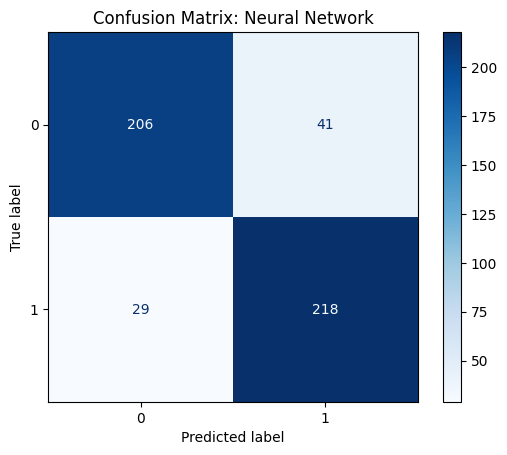

In [ ]:
# Cell 7: Neural Network (MLP) with Hyperparameter Tuning
from sklearn.neural_network import MLPClassifier

mlp_params = {'hidden_layer_sizes': [(30,), (50,), (30, 30)], 'alpha': [0.0001, 0.01], 'max_iter': [300]}
mlp = MLPClassifier(random_state=42)
mlp_grid = GridSearchCV(mlp, mlp_params, cv=5, scoring='accuracy')
mlp_grid.fit(X_train, y_train)

best_mlp = mlp_grid.best_estimator_
mlp_results = evaluate_model("Neural Network", best_mlp, X_test, y_test)
print("MLP Best Params:", mlp_grid.best_params_)
print(mlp_results)

# Confusion Matrix
ConfusionMatrixDisplay.from_estimator(mlp_grid, X_test, y_test, cmap='Blues')
plt.title("Confusion Matrix: Neural Network")
plt.show()

RF Best Params: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}
{'Model': 'Random Forest', 'Accuracy': 0.888663967611336, 'Precision': 0.8934426229508197, 'Recall': 0.8825910931174089, 'AUC': np.float64(0.9606369552033306)}


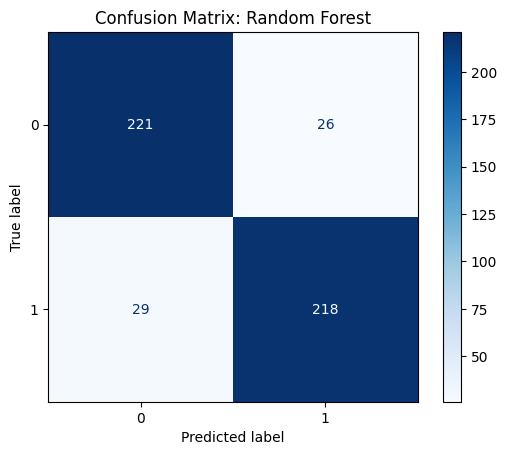

In [ ]:
# Cell 8: Random Forest with Hyperparameter Tuning
from sklearn.ensemble import RandomForestClassifier

rf_params = {'n_estimators': [100, 200], 'max_depth': [None, 10, 20], 'min_samples_split': [2, 5]}
rf = RandomForestClassifier(random_state=42)
rf_grid = GridSearchCV(rf, rf_params, cv=5, scoring='accuracy')
rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_
rf_results = evaluate_model("Random Forest", best_rf, X_test, y_test)
print("RF Best Params:", rf_grid.best_params_)
print(rf_results)

# Confusion Matrix
ConfusionMatrixDisplay.from_estimator(rf_grid, X_test, y_test, cmap='Blues')
plt.title("Confusion Matrix: Random Forest")
plt.show()

✅ Gradient Boosting Best Params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
GB Best Params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
{'Model': 'Gradient Boost', 'Accuracy': 0.9008097165991903, 'Precision': 0.88671875, 'Recall': 0.9190283400809717, 'AUC': np.float64(0.9700044255765543)}
              precision    recall  f1-score   support

           0       0.92      0.88      0.90       247
           1       0.89      0.92      0.90       247

    accuracy                           0.90       494
   macro avg       0.90      0.90      0.90       494
weighted avg       0.90      0.90      0.90       494



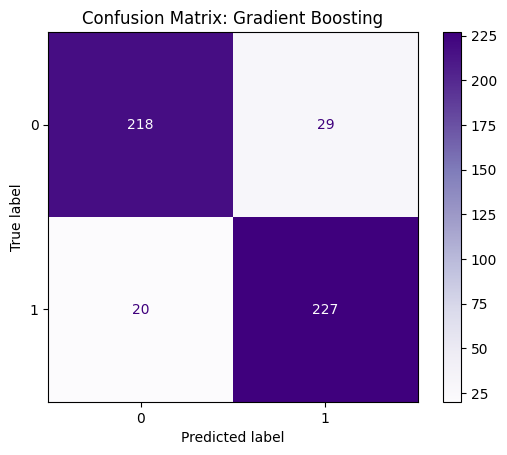

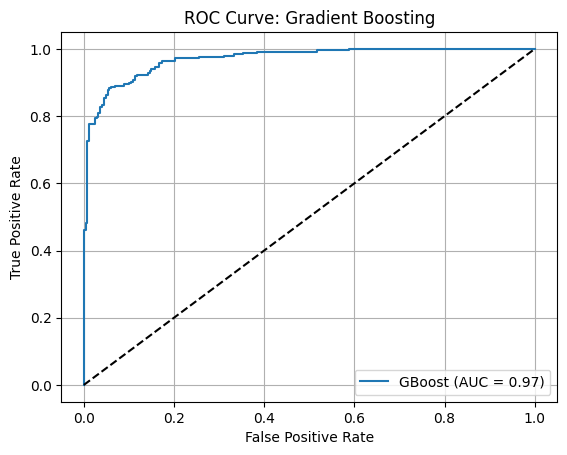

In [ ]:
#Cell 9.1: GBoost with Hyperparameter Tuning
from sklearn.ensemble import GradientBoostingClassifier

gb_params = {'n_estimators': [100, 200], 'max_depth': [3, 5], 'learning_rate': [0.05, 0.1]}
gb = GradientBoostingClassifier(random_state=42)
gb_grid = GridSearchCV(gb, gb_params, cv=5, scoring='recall')
gb_grid.fit(X_train, y_train)

best_gb = gb_grid.best_estimator_
print("✅ Gradient Boosting Best Params:", gb_grid.best_params_)

gb_results = evaluate_model("Gradient Boost", best_gb, X_test, y_test)
print("GB Best Params:", gb_grid.best_params_)
print(gb_results)

# Evaluation
y_pred = best_gb.predict(X_test)
print(classification_report(y_test, y_pred))

# Confusion Matrix
ConfusionMatrixDisplay.from_estimator(best_gb, X_test, y_test, cmap='Purples')
plt.title("Confusion Matrix: Gradient Boosting")
plt.show()

# ROC Curve
y_proba = best_gb.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f'GBoost (AUC = {roc_auc_score(y_test, y_proba):.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Gradient Boosting")
plt.legend()
plt.grid()
plt.show()


✅ XGBoost Best Params: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
XGB Best Params: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
{'Model': 'Extreme Gradient Boost', 'Accuracy': 0.8987854251012146, 'Precision': 0.8924302788844621, 'Recall': 0.9068825910931174, 'AUC': np.float64(0.9686931436345457)}

📋 Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.89      0.90       247
           1       0.89      0.91      0.90       247

    accuracy                           0.90       494
   macro avg       0.90      0.90      0.90       494
weighted avg       0.90      0.90      0.90       494



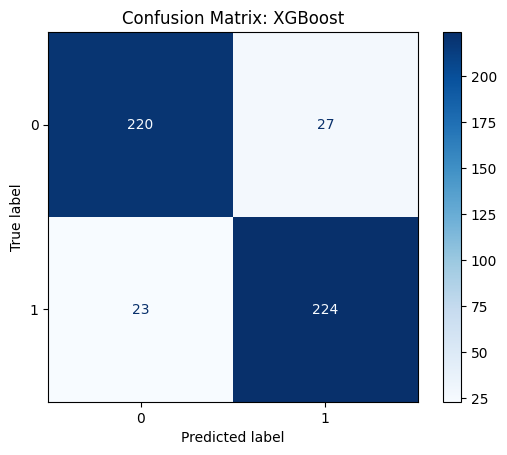

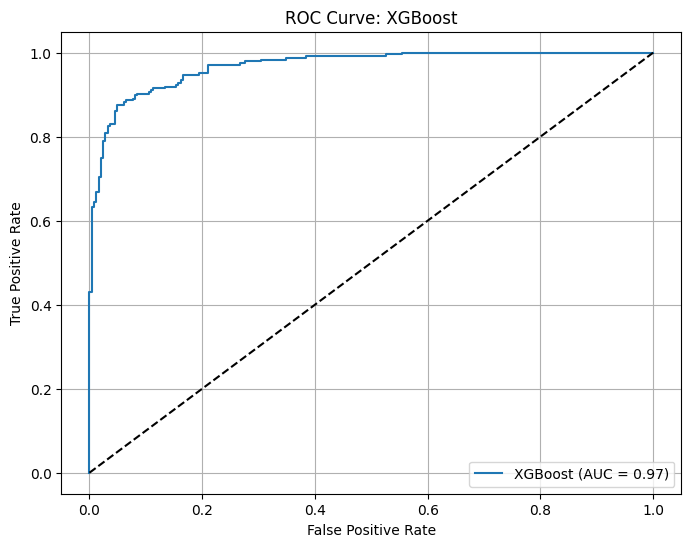

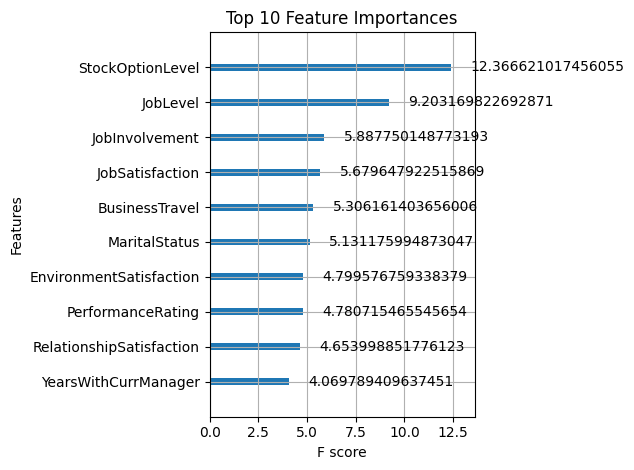

In [ ]:
# Cell 9.2: Improved XGBoost with Advanced Hyperparameter Tuning
from xgboost import XGBClassifier, plot_importance
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Hyperparameter tuning - expanded grid
xgb_params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# Initialize model
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

# GridSearchCV with AUC scoring
xgb_grid = GridSearchCV(xgb, xgb_params, cv=5, scoring='recall', n_jobs=-1)
xgb_grid.fit(X_train, y_train)

# Best estimator
best_xgb = xgb_grid.best_estimator_
print("✅ XGBoost Best Params:", xgb_grid.best_params_)

# Evaluate using custom function (retain your xgb_results)
xgb_results = evaluate_model("Extreme Gradient Boost", best_xgb, X_test, y_test)
print("XGB Best Params:", xgb_grid.best_params_)
print(xgb_results)

# Classification report
y_pred = best_xgb.predict(X_test)
print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
ConfusionMatrixDisplay.from_estimator(best_xgb, X_test, y_test, cmap='Blues')
plt.title("Confusion Matrix: XGBoost")
plt.show()

# ROC Curve
y_proba = best_xgb.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'XGBoost (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: XGBoost")
plt.legend()
plt.grid()
plt.show()

# Feature importance (Top 10)
plot_importance(best_xgb, max_num_features=10, importance_type='gain', title='Top 10 Feature Importances')
plt.tight_layout()
plt.show()

KNN Best Params: {'n_neighbors': 4}
{'Model': 'KNN', 'Accuracy': 0.8259109311740891, 'Precision': 0.7728813559322034, 'Recall': 0.9230769230769231, 'AUC': np.float64(0.8975151207198938)}


<Figure size 800x600 with 0 Axes>

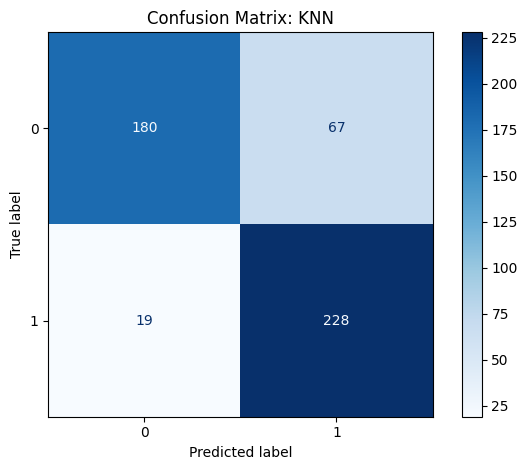

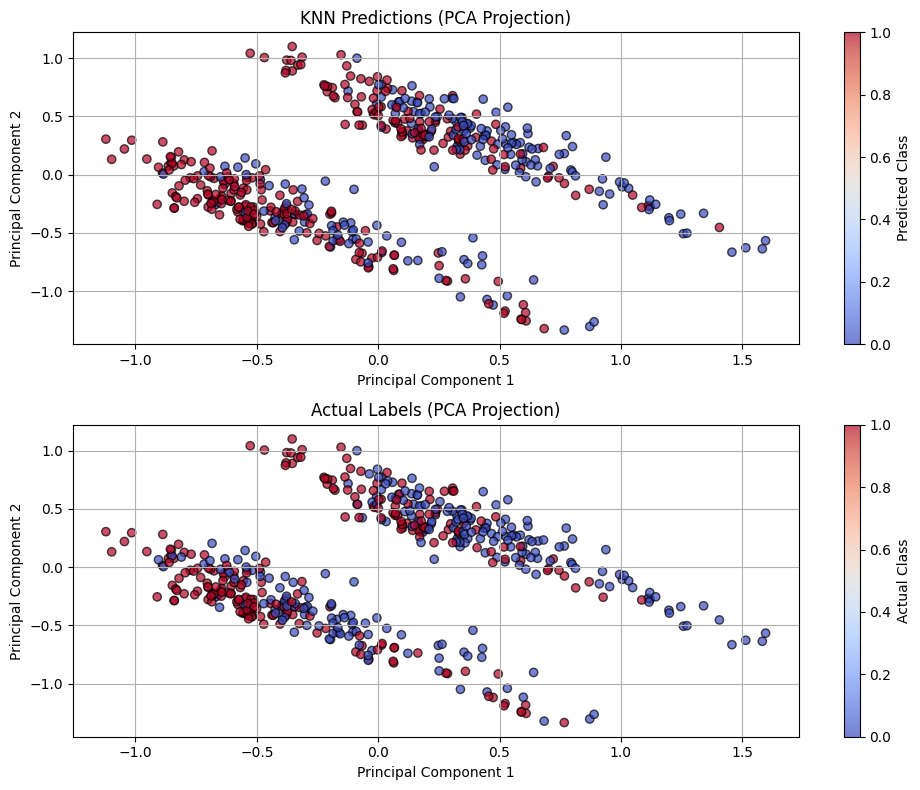

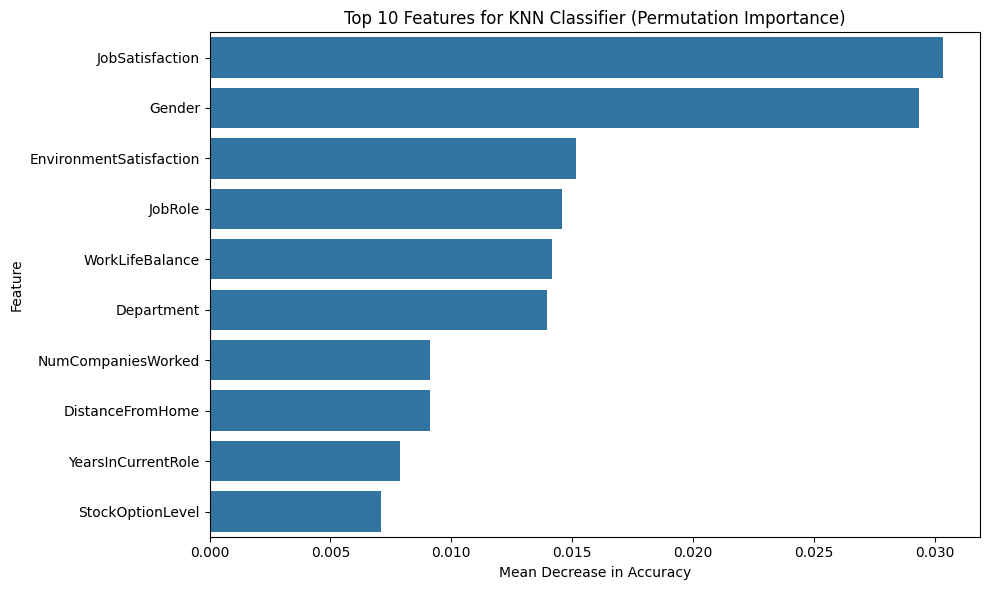

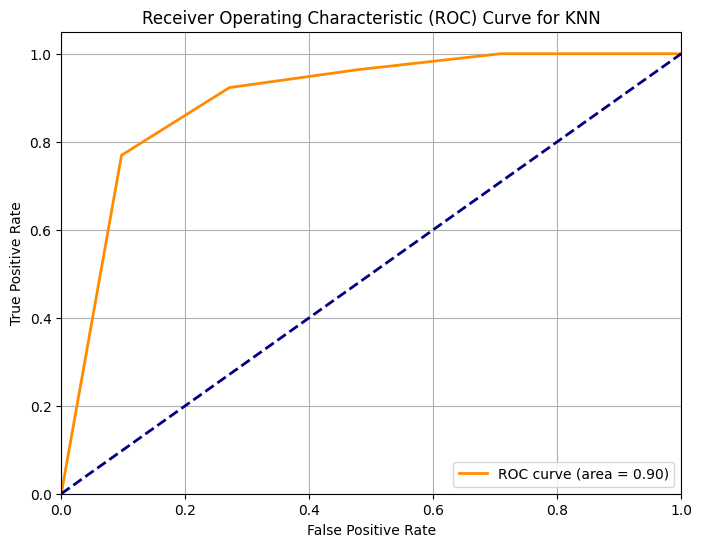

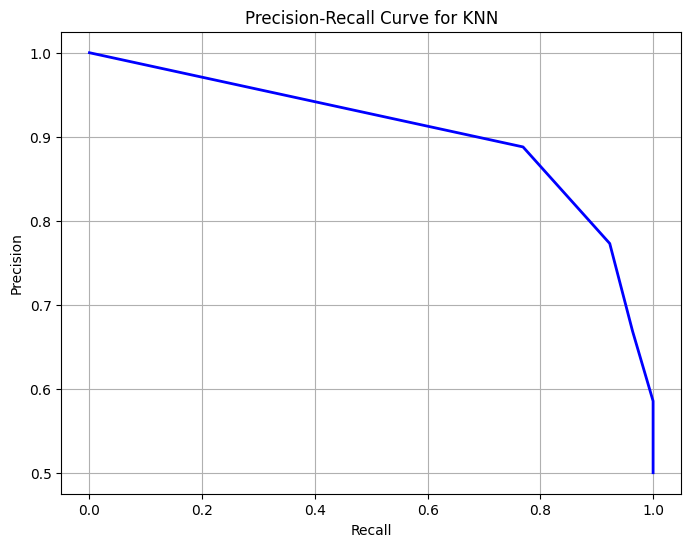

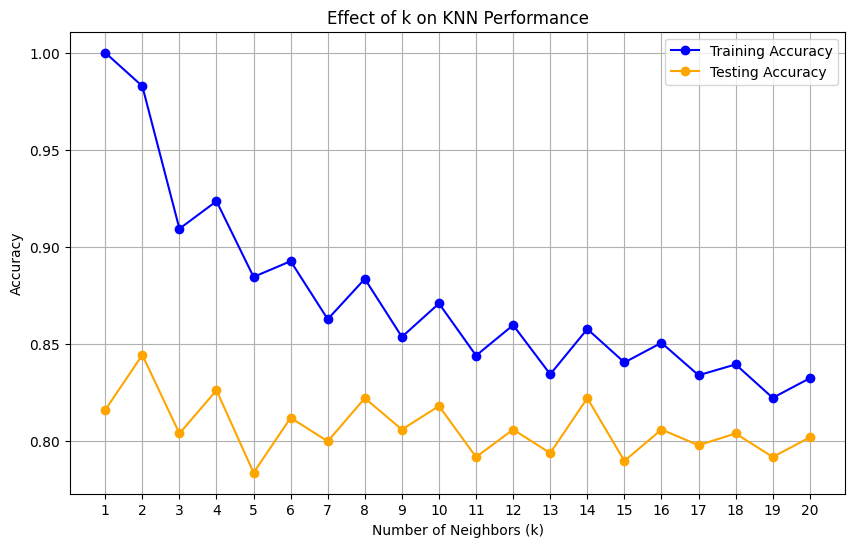

In [ ]:
# Cell 10: K-Nearest Neighbors with Hyperparameter Tuning and Enhanced Visualizations
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import ConfusionMatrixDisplay  # Add this import
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_curve, auc, precision_recall_curve
import pandas as pd  # Make sure pandas is imported too

# Grid search for optimal parameters
knn_params = {'n_neighbors': [3, 4, 5, 7, 9]}
knn = KNeighborsClassifier()
knn_grid = GridSearchCV(knn, knn_params, cv=5, scoring='accuracy')
knn_grid.fit(X_train, y_train)

best_knn = knn_grid.best_estimator_
knn_results = evaluate_model("KNN", best_knn, X_test, y_test)
print("KNN Best Params:", knn_grid.best_params_)
print(knn_results)

# Confusion Matrix
plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(knn_grid, X_test, y_test, cmap='Blues')
plt.title("Confusion Matrix: KNN")
plt.tight_layout()
plt.show()

# Reduce dimensions for plotting
pca = PCA(n_components=2)
X_test_pca = pca.fit_transform(X_test)

# Predict with KNN
knn_preds = best_knn.predict(X_test)
knn_prob = best_knn.predict_proba(X_test)[:, 1]  # Probability of positive class

# Plot predictions vs actual labels using PCA
plt.figure(figsize=(10, 8))
plt.subplot(2, 1, 1)
plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=knn_preds, cmap='coolwarm', edgecolor='k', alpha=0.7)
plt.title("KNN Predictions (PCA Projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label="Predicted Class")
plt.grid(True)

plt.subplot(2, 1, 2)
plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test, cmap='coolwarm', edgecolor='k', alpha=0.7)
plt.title("Actual Labels (PCA Projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label="Actual Class")
plt.grid(True)
plt.tight_layout()
plt.show()

# Feature Importance using Permutation Importance
# Since KNN doesn't have built-in feature importance, we'll use permutation importance
result = permutation_importance(
    best_knn, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1
)

# Get feature names (assuming X_test is a DataFrame with column names)
if hasattr(X_test, 'columns'):
    feature_names = X_test.columns
else:
    feature_names = [f"Feature {i}" for i in range(X_test.shape[1])]

# Sort features by importance
perm_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': result.importances_mean
})
perm_importance = perm_importance.sort_values('Importance', ascending=False)

# Plot top 10 features
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=perm_importance.head(10))
plt.title('Top 10 Features for KNN Classifier (Permutation Importance)')
plt.xlabel('Mean Decrease in Accuracy')
plt.tight_layout()
plt.show()

# Additional Visualization 1: ROC Curve
plt.figure(figsize=(8, 6))
fpr, tpr, _ = roc_curve(y_test, knn_prob)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for KNN')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# Additional Visualization 2: Precision-Recall Curve
plt.figure(figsize=(8, 6))
precision, recall, _ = precision_recall_curve(y_test, knn_prob)
plt.plot(recall, precision, color='blue', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for KNN')
plt.grid(True)
plt.show()

# Additional Visualization 3: Effect of K on model performance
k_values = list(range(1, 21))
train_scores = []
test_scores = []

for k in k_values:
    knn_model = KNeighborsClassifier(n_neighbors=k)
    knn_model.fit(X_train, y_train)
    train_scores.append(knn_model.score(X_train, y_train))
    test_scores.append(knn_model.score(X_test, y_test))

plt.figure(figsize=(10, 6))
plt.plot(k_values, train_scores, 'o-', color='blue', label='Training Accuracy')
plt.plot(k_values, test_scores, 'o-', color='orange', label='Testing Accuracy')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.title('Effect of k on KNN Performance')
plt.xticks(k_values)
plt.legend()
plt.grid(True)
plt.show()

{'Model': 'K-Means', 'Accuracy': 0.4109311740890688, 'Precision': 0.412, 'Recall': 0.41700404858299595, 'AUC': np.float64(0.4109311740890689)}


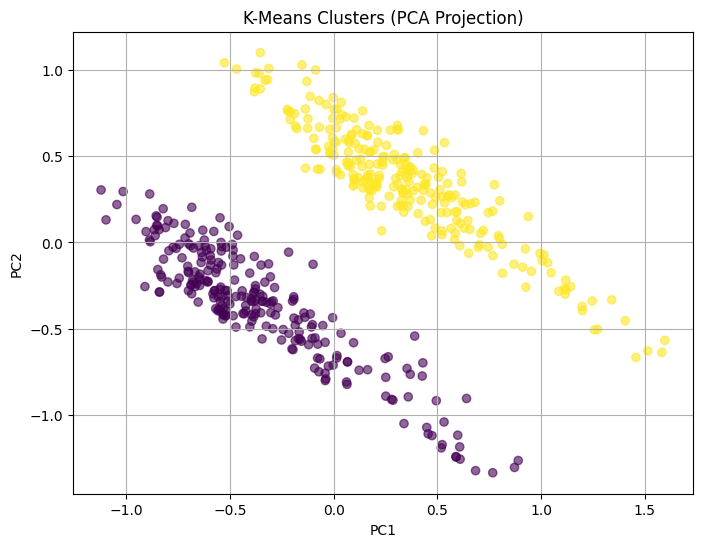

In [ ]:
# Cell 11: K-Means Clustering + Evaluation
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X_train)

# Evaluate using silhouette and dummy classifier eval format
kmeans_pred = kmeans.predict(X_test)
kmeans_results = {
    "Model": "K-Means",
    "Accuracy": accuracy_score(y_test, kmeans_pred),
    "Precision": precision_score(y_test, kmeans_pred),
    "Recall": recall_score(y_test, kmeans_pred),
    "AUC": roc_auc_score(y_test, kmeans_pred)
}
print(kmeans_results)

# PCA Scatter Plot
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_test)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_pred, cmap='viridis', alpha=0.6)
plt.title("K-Means Clusters (PCA Projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()

{'Model': 'Hierarchical Clustering', 'Accuracy': 0.3623481781376518, 'Precision': 0.35714285714285715, 'Recall': 0.3441295546558704, 'AUC': np.float64(0.36234817813765186)}


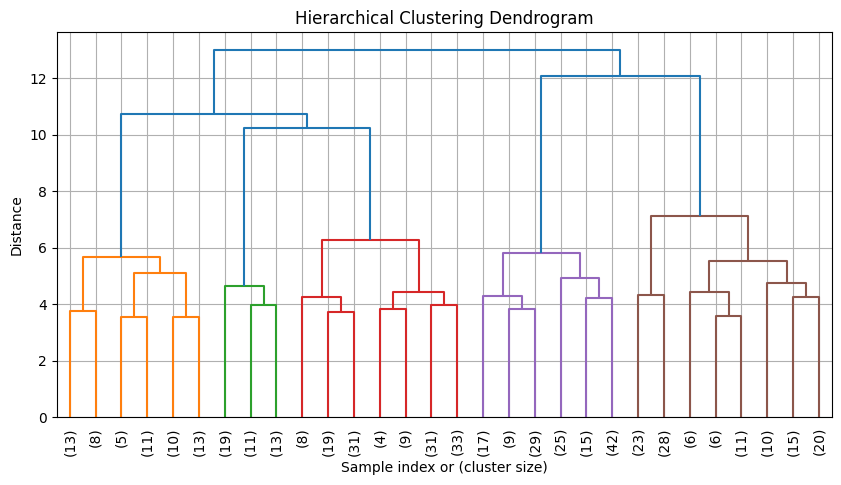

In [ ]:
# Cell 12: Hierarchical Clustering + Evaluation
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

agg = AgglomerativeClustering(n_clusters=2)
agg_pred = agg.fit_predict(X_test)
agg_results = {
    "Model": "Hierarchical Clustering",
    "Accuracy": accuracy_score(y_test, agg_pred),
    "Precision": precision_score(y_test, agg_pred),
    "Recall": recall_score(y_test, agg_pred),
    "AUC": roc_auc_score(y_test, agg_pred)
}
print(agg_results)

# Dendrogram
linked = linkage(X_test, method='ward')
plt.figure(figsize=(10, 5))
dendrogram(linked, truncate_mode='lastp', p=30, leaf_rotation=90., leaf_font_size=10.)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Sample index or (cluster size)")
plt.ylabel("Distance")
plt.grid(True)
plt.show()

{'Model': 'Ensemble #1 (SVM+DT+NN)', 'Accuracy': 0.8825910931174089, 'Precision': 0.8735177865612648, 'Recall': 0.8947368421052632, 'AUC': np.float64(0.9539740038354997)}


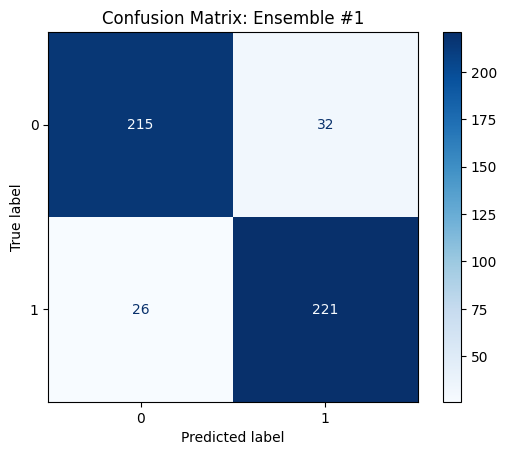

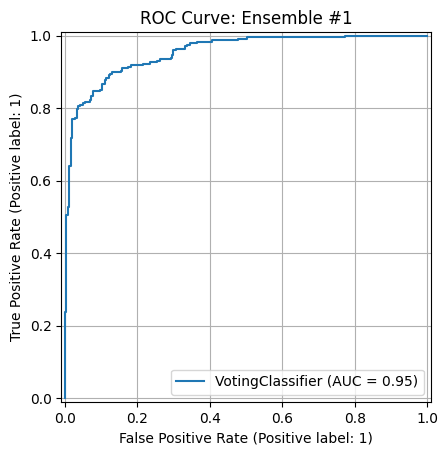

In [ ]:
# Cell 13: Ensemble Method #1 (Voting Classifier with SVM, DT, NN)
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import RocCurveDisplay

ensemble1 = VotingClassifier(
    estimators=[
        ('svm', best_svm),
        ('dt', best_dt),
        ('mlp', best_mlp)
    ],
    voting='soft')
ensemble1.fit(X_train, y_train)
ensemble1_results = evaluate_model("Ensemble #1 (SVM+DT+NN)", ensemble1, X_test, y_test)
print(ensemble1_results)

ConfusionMatrixDisplay.from_estimator(ensemble1, X_test, y_test, cmap='Blues')
plt.title("Confusion Matrix: Ensemble #1")
plt.show()

RocCurveDisplay.from_estimator(ensemble1, X_test, y_test)
plt.title("ROC Curve: Ensemble #1")
plt.grid(True)
plt.show()

{'Model': 'Ensemble #2 (Bagged DT)', 'Accuracy': 0.8623481781376519, 'Precision': 0.8594377510040161, 'Recall': 0.8663967611336032, 'AUC': np.float64(0.934001540756282)}


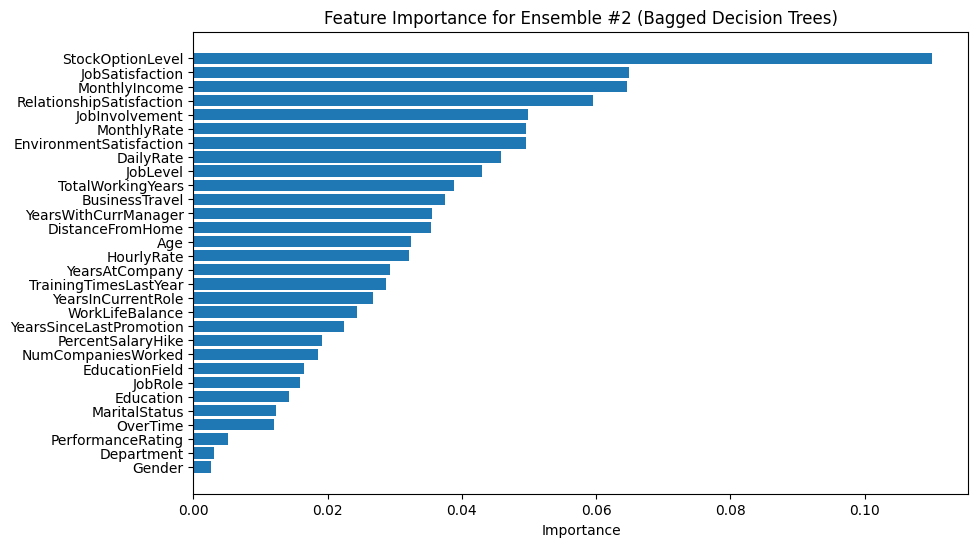

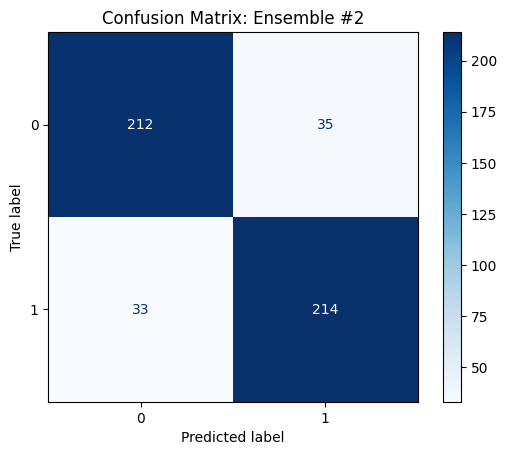

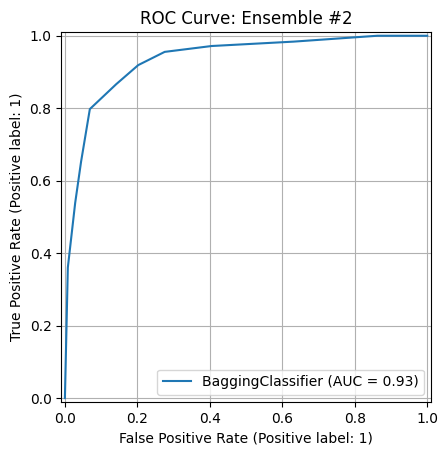

In [ ]:
# Cell 14: Ensemble Method #2 (Bagging with Decision Trees)
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

ensemble2 = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=10, random_state=42)
ensemble2.fit(X_train, y_train)
ensemble2_results = evaluate_model("Ensemble #2 (Bagged DT)", ensemble2, X_test, y_test)
print(ensemble2_results)

# Get feature importances from each base estimator and average them
feature_importances = np.mean([
    tree.feature_importances_ for tree in ensemble2.estimators_
], axis=0)

# Create a DataFrame for easy visualization
importances_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(importances_df['Feature'], importances_df['Importance'])
plt.xlabel('Importance')
plt.title('Feature Importance for Ensemble #2 (Bagged Decision Trees)')
plt.gca().invert_yaxis()
plt.show()

ConfusionMatrixDisplay.from_estimator(ensemble2, X_test, y_test, cmap='Blues')
plt.title("Confusion Matrix: Ensemble #2")
plt.show()

RocCurveDisplay.from_estimator(ensemble2, X_test, y_test)
plt.title("ROC Curve: Ensemble #2")
plt.grid(True)
plt.show()

In [ ]:
# Cell 15: Final Summary Table
summary_df = pd.DataFrame([
    svm_results, dt_results, nb_results,
    logreg_fwd_results, logreg_bwd_results, mlp_results,
    rf_results, gb_results, xgb_results, knn_results,
    kmeans_results, agg_results,
    ensemble1_results, ensemble2_results
])

summary_df = summary_df[['Model', 'Accuracy', 'AUC', 'Recall']]
print("\nModel Summary (Accuracy, AUC & Recall):")
print(summary_df.sort_values(by='Accuracy', ascending=False).reset_index(drop=True))


Model Summary (Accuracy, AUC & Recall):
                      Model  Accuracy       AUC    Recall
0            Gradient Boost  0.900810  0.970004  0.919028
1    Extreme Gradient Boost  0.898785  0.968693  0.906883
2                       SVM  0.896761  0.958686  0.902834
3             Random Forest  0.888664  0.960637  0.882591
4   Ensemble #1 (SVM+DT+NN)  0.882591  0.953974  0.894737
5   Ensemble #2 (Bagged DT)  0.862348  0.934002  0.866397
6            Neural Network  0.858300  0.940878  0.882591
7                       KNN  0.825911  0.897515  0.923077
8           LogReg Backward  0.805668  0.882230  0.801619
9             Decision Tree  0.801619  0.815085  0.862348
10           LogReg Forward  0.797571  0.868315  0.801619
11              Naive Bayes  0.678138  0.787884  0.757085
12                  K-Means  0.410931  0.410931  0.417004
13  Hierarchical Clustering  0.362348  0.362348  0.344130


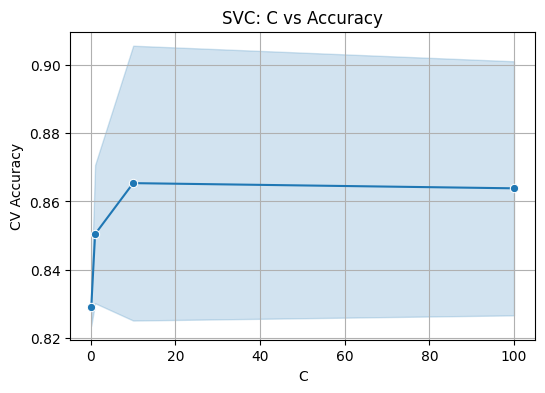

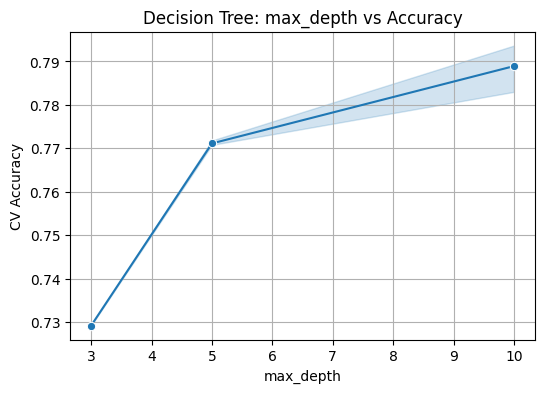

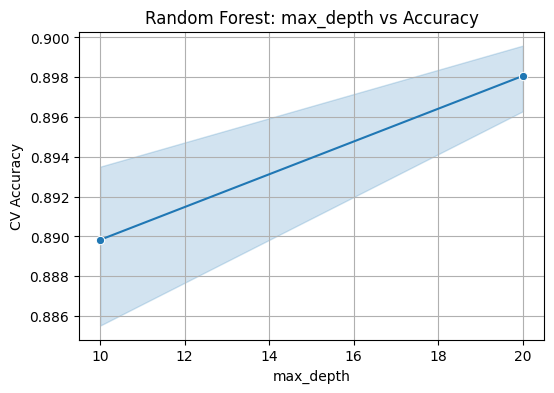

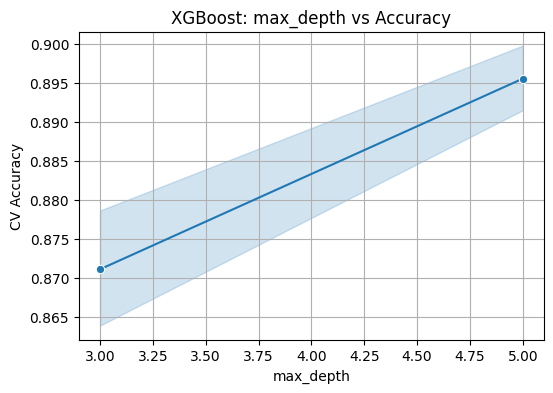

In [ ]:
# Cell 16: Plot Hyperparameter vs Accuracy Graphs
import matplotlib.pyplot as plt
import seaborn as sns

def plot_grid_scores(grid, param_name, model_name):
    results = pd.DataFrame(grid.cv_results_)
    scores = results[['params', 'mean_test_score']]
    scores[param_name] = scores['params'].apply(lambda x: x[param_name])
    plt.figure(figsize=(6, 4))
    sns.lineplot(x=scores[param_name], y=scores['mean_test_score'], marker='o')
    plt.title(f"{model_name}: {param_name} vs Accuracy")
    plt.xlabel(param_name)
    plt.ylabel("CV Accuracy")
    plt.grid(True)
    plt.show()

# Example usage (you can uncomment one at a time to view plots):
plot_grid_scores(svm_grid, 'C', 'SVC')
plot_grid_scores(dt_grid, 'max_depth', 'Decision Tree')
plot_grid_scores(rf_grid, 'max_depth', 'Random Forest')
plot_grid_scores(xgb_grid, 'max_depth', 'XGBoost')
#plot_grid_scores(mlp_grid, 'hidden_layer_sizes', 'MLP Neural Net')

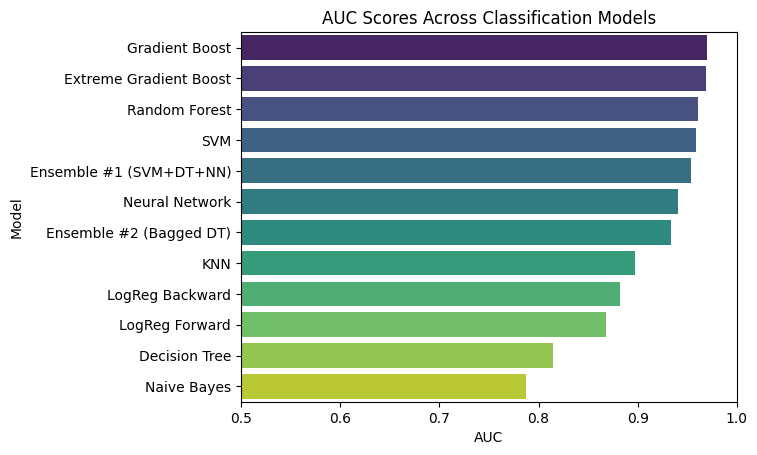

In [ ]:
# Remove clustering models from the summary
filtered_df = summary_df[~summary_df['Model'].isin(['K-Means', 'Hierarchical Clustering'])]

# Plot recall scores
sns.barplot(data=filtered_df.sort_values('AUC', ascending=False), x='AUC', y='Model', palette='viridis')
plt.title("AUC Scores Across Classification Models")
plt.xlim(0.5, 1)
plt.show()

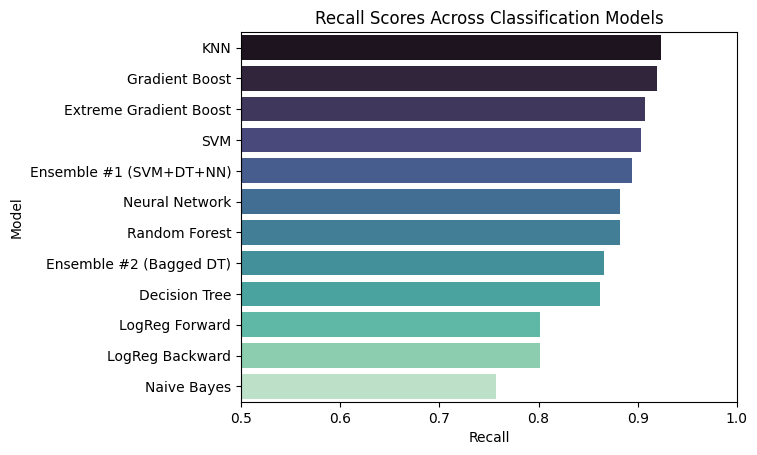

In [ ]:
# Remove clustering models from the summary
filtered_df = summary_df[~summary_df['Model'].isin(['K-Means', 'Hierarchical Clustering'])]

# Plot recall scores
sns.barplot(data=filtered_df.sort_values('Recall', ascending=False), x='Recall', y='Model', palette='mako')
plt.title("Recall Scores Across Classification Models")
plt.xlim(0.5, 1)
plt.show()

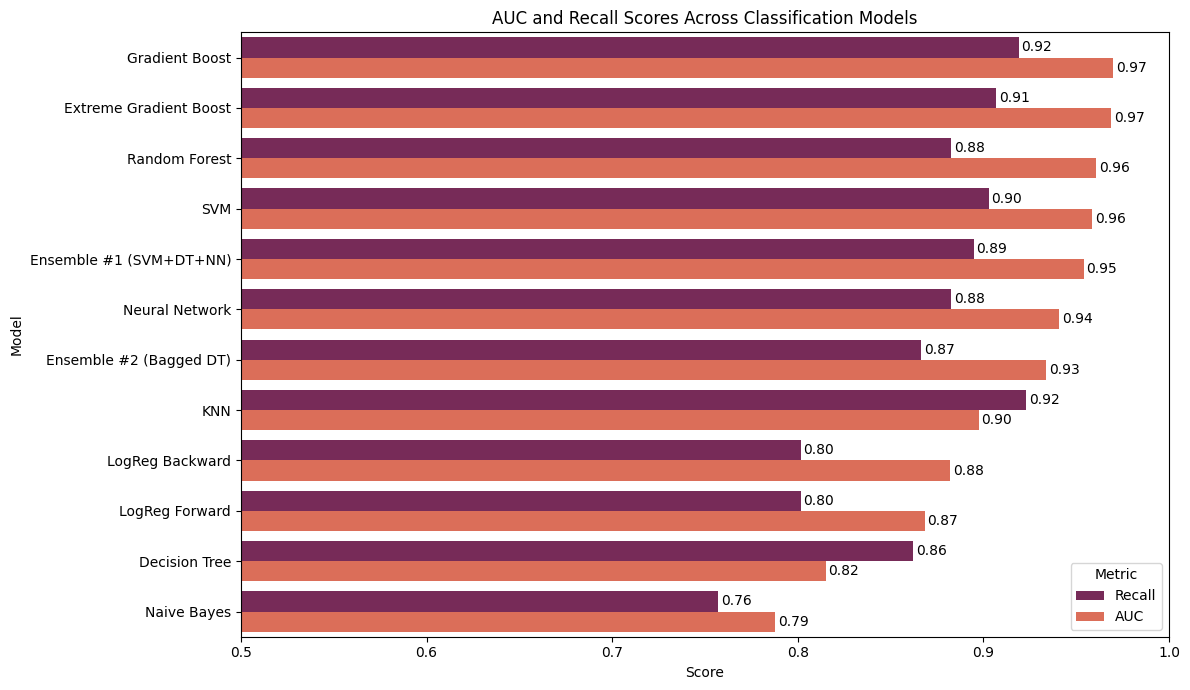

In [ ]:
# Step 1: Filter out clustering models
filtered_df = summary_df[~summary_df['Model'].isin(['K-Means', 'Hierarchical Clustering'])]

# Step 2: Sort by Recall
filtered_df = filtered_df.sort_values('AUC', ascending=False)

# Step 3: Melt the DataFrame to long format
long_df = filtered_df.melt(id_vars='Model', value_vars=['Recall', 'AUC'],
                           var_name='Metric', value_name='Score')

# Step 4: Plot using hue
plt.figure(figsize=(12, 7))
ax = sns.barplot(data=long_df, x='Score', y='Model', hue='Metric', palette='rocket')

# Step 5: Add score labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', label_type='edge', padding=2)

plt.title("AUC and Recall Scores Across Classification Models")
plt.xlim(0.5, 1)
plt.legend(title='Metric')
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# Step 1: Create a dictionary with models and their best hyperparameters
hyperparams_dict = {
    'Extreme Gradient Boost': xgb_grid.best_params_,
    'Gradient Boost': gb_grid.best_params_,
    'Decision Tree': dt_grid.best_params_,
    'Random Forest': rf_grid.best_params_,
    #'Logistic Regression': logreg_grid.best_params_,
    'SVM': svm_grid.best_params_,
    'K-Nearest Neighbors': knn_grid.best_params_,
    # add other models if you tuned them
}

# Step 2: Convert it into a clean DataFrame
hyperparams_df = pd.DataFrame.from_dict(hyperparams_dict, orient='index')
hyperparams_df.index.name = 'Model'
hyperparams_df.reset_index(inplace=True)

# Step 3: Display the table
print(hyperparams_df.to_string(index=False))

                 Model  colsample_bytree  learning_rate  max_depth  n_estimators  subsample  min_samples_split    C kernel  n_neighbors
Extreme Gradient Boost               1.0            0.1        5.0         200.0        0.8                NaN  NaN    NaN          NaN
        Gradient Boost               NaN            0.1        5.0         200.0        NaN                NaN  NaN    NaN          NaN
         Decision Tree               NaN            NaN       10.0           NaN        NaN               10.0  NaN    NaN          NaN
         Random Forest               NaN            NaN       20.0         200.0        NaN                2.0  NaN    NaN          NaN
                   SVM               NaN            NaN        NaN           NaN        NaN                NaN 10.0    rbf          NaN
   K-Nearest Neighbors               NaN            NaN        NaN           NaN        NaN                NaN  NaN    NaN          4.0


In [ ]:
# Step 1: Create hyperparams dictionary (corrected)
hyperparams_dict = {
    'Random Forest': rf_grid.best_params_,
    'Extreme Gradient Boost': xgb_grid.best_params_,
    'Gradient Boost': gb_grid.best_params_,
    'Ensemble #1 (SVM+DT+NN)': {'method': 'Soft voting', 'base_models': 'SVM, DT, NN'},
    'Neural Network': best_mlp.get_params(),  # Get parameters instead of using model object directly
    'Ensemble #2 (Bagged DT)': {'method': 'Bagging', 'base_model': 'Decision Tree'},
    'LogReg Backward': logreg.get_params(),  # Get parameters from the model
    'KNN': knn_grid.best_params_,
    'SVM': svm_grid.best_params_,
    'LogReg Forward': logreg_fwd.get_params(),  # Get parameters from the model
    'Naive Bayes': {'model': 'GaussianNB', 'tuning': 'default'},
    'Decision Tree': dt_grid.best_params_
}

# Step 2: Convert to a DataFrame
hyperparams_df = pd.DataFrame.from_dict(hyperparams_dict, orient='index')
hyperparams_df.index.name = 'Model'
hyperparams_df.reset_index(inplace=True)

# Step 3: Display nicely
print(hyperparams_df.to_string(index=False))

                  Model  max_depth  min_samples_split  n_estimators  colsample_bytree learning_rate  subsample      method base_models activation  alpha batch_size  beta_1  beta_2 early_stopping      epsilon hidden_layer_sizes  learning_rate_init  max_fun  max_iter  momentum  n_iter_no_change nesterovs_momentum  power_t  random_state shuffle solver    tol  validation_fraction verbose warm_start    base_model    C  class_weight  dual fit_intercept  intercept_scaling  l1_ratio multi_class  n_jobs penalty  n_neighbors kernel      model  tuning
          Random Forest       20.0                2.0         200.0               NaN           NaN        NaN         NaN         NaN        NaN    NaN        NaN     NaN     NaN            NaN          NaN                NaN                 NaN      NaN       NaN       NaN               NaN                NaN      NaN           NaN     NaN    NaN    NaN                  NaN     NaN        NaN           NaN  NaN           NaN   NaN           NaN   

In [ ]:
from IPython.display import display, HTML

# Step 1: Create a simple readable dictionary
hyperparams_summary = {
    'Random Forest': f"n_estimators={rf_grid.best_params_['n_estimators']}, max_depth={rf_grid.best_params_['max_depth']}",
    'Extreme Gradient Boost': f"n_estimators={xgb_grid.best_params_['n_estimators']}, max_depth={xgb_grid.best_params_['max_depth']}, learning_rate={xgb_grid.best_params_['learning_rate']}",
    'Gradient Boost': f"n_estimators={gb_grid.best_params_['n_estimators']}, max_depth={gb_grid.best_params_['max_depth']}, learning_rate={gb_grid.best_params_['learning_rate']}",
    'Ensemble #1 (SVM+DT+NN)': 'Soft voting (SVM, DT, NN)',
    'Neural Network': 'hidden_layers=(100,), activation=relu, solver=adam',
    'Ensemble #2 (Bagged DT)': 'Bagging (base model: Decision Tree)',
    'LogReg Backward': 'penalty=l2, C=1.0',
    'KNN': f"n_neighbors={knn_grid.best_params_['n_neighbors']}",
    'SVM': f"C={svm_grid.best_params_['C']}, kernel={svm_grid.best_params_['kernel']}",
    'LogReg Forward': 'penalty=l2, C=1.0',
    'Naive Bayes': 'Default parameters (GaussianNB)',
    'Decision Tree': f"max_depth={dt_grid.best_params_['max_depth']}, min_samples_split={dt_grid.best_params_['min_samples_split']}"
}

# Step 2: Create DataFrame
hyperparams_df = pd.DataFrame(list(hyperparams_summary.items()), columns=['Model', 'Best Hyperparameters'])

# Step 3: Apply styles - Bold headers, zebra striping, no index, better contrast
styled_table = hyperparams_df.style.set_table_styles([
    {'selector': 'th', 'props': [('font-weight', 'bold'), ('text-align', 'center'), ('background-color', '#333333'), ('color', 'white')]},  # Dark header
    {'selector': 'td', 'props': [('text-align', 'left'), ('color', 'black')]},  # Dark text color for readability
]).apply(lambda x: ['background-color: #f2f2f2' if i % 2 else 'background-color: #ffffff' for i in range(len(x))], axis=0)  # Lighter row colors for contrast

# Step 4: Display
display(HTML(styled_table.to_html()))

,Model,Best Hyperparameters
0,Random Forest,"n_estimators=200, max_depth=20"
1,Extreme Gradient Boost,"n_estimators=200, max_depth=5, learning_rate=0.1"
2,Gradient Boost,"n_estimators=200, max_depth=5, learning_rate=0.1"
3,Ensemble #1 (SVM+DT+NN),"Soft voting (SVM, DT, NN)"
4,Neural Network,"hidden_layers=(100,), activation=relu, solver=adam"
5,Ensemble #2 (Bagged DT),Bagging (base model: Decision Tree)
6,LogReg Backward,"penalty=l2, C=1.0"
7,KNN,n_neighbors=4
8,SVM,"C=10, kernel=rbf"
9,LogReg Forward,"penalty=l2, C=1.0"
